In [6]:
import pandas as pd
import os

# Dossier racine contenant les CSV
racine = r"C:\Projet-IESE5-Localisation\Résultat mesures"

# Dictionnaire pour stocker les 100 mesures centrales de chaque fichier
mesures = {}

# Parcourir récursivement tous les fichiers CSV
for dirpath, dirnames, filenames in os.walk(racine):
    for filename in filenames:
        if filename.endswith(".csv"):
            chemin = os.path.join(dirpath, filename)
            # Chemin relatif pour identifier le fichier
            cle = os.path.relpath(chemin, racine)
            
            df = pd.read_csv(chemin)
            n = len(df)
            
            # Extraire 100 mesures au milieu
            debut = (n - 100) // 2
            fin = debut + 100
            df_milieu = df.iloc[debut:fin]
            
            # Stocker la colonne "Distance (m)"
            mesures[cle] = df_milieu["Distance (m)"].reset_index(drop=True)
            print(f"{cle}: {n} lignes → extrait lignes {debut} à {fin-1}")

# Créer un DataFrame récapitulatif avec toutes les mesures
df_mesures = pd.DataFrame(mesures)
print(f"\nDataFrame final : {df_mesures.shape}")
df_mesures.head(10)

extérieur\canal 5\10m extérieur ds sans obstacles canal 5.csv: 197 lignes → extrait lignes 48 à 147
extérieur\canal 5\1m extérieur ds sans obstacles canal 5.csv: 200 lignes → extrait lignes 50 à 149
extérieur\canal 5\20m ds sans obstacles canal 5.csv: 128 lignes → extrait lignes 14 à 113
extérieur\canal 5\3m extérieur ds sans obstacles canal 5.csv: 155 lignes → extrait lignes 27 à 126
extérieur\canal 5\5m extérieur ds sans obstacles canal 5.csv: 128 lignes → extrait lignes 14 à 113
extérieur\canal 9\10M ds extérieur obstacle humain.csv: 129 lignes → extrait lignes 14 à 113
extérieur\canal 9\10M ds extérieur sans obstacles.csv: 120 lignes → extrait lignes 10 à 109
extérieur\canal 9\1M ds extérieur obstacle humain.csv: 144 lignes → extrait lignes 22 à 121
extérieur\canal 9\1M ds extérieur sans obstacles.csv: 155 lignes → extrait lignes 27 à 126
extérieur\canal 9\20M ds extérieur sans obstacles.csv: 148 lignes → extrait lignes 24 à 123
extérieur\canal 9\3M ds extérieur avec obstacles huma

,extérieur\canal 5\10m extérieur ds sans obstacles canal 5.csv,extérieur\canal 5\1m extérieur ds sans obstacles canal 5.csv,extérieur\canal 5\20m ds sans obstacles canal 5.csv,extérieur\canal 5\3m extérieur ds sans obstacles canal 5.csv,extérieur\canal 5\5m extérieur ds sans obstacles canal 5.csv,extérieur\canal 9\10M ds extérieur obstacle humain.csv,extérieur\canal 9\10M ds extérieur sans obstacles.csv,extérieur\canal 9\1M ds extérieur obstacle humain.csv,extérieur\canal 9\1M ds extérieur sans obstacles.csv,extérieur\canal 9\20M ds extérieur sans obstacles.csv,...,intérieur\double side\Obstacle métal\5m avec métal.csv,intérieur\double side\Obstacle métal\9m avec métal.csv,intérieur\double side\Sans obstacles\1m sans obstacles.csv,intérieur\double side\Sans obstacles\3m sans obsctacles.csv,intérieur\double side\Sans obstacles\5m sans obstacles.csv,intérieur\double side\Sans obstacles\9m sans obstacles.csv,intérieur\single side\1m single side sans obstacles.csv,intérieur\single side\3m ss sans obstacles.csv,intérieur\single side\5m ss sans obsctacles.csv,intérieur\single side\9m ss sans obstacles.csv
0,10.15,0.88,20.05,2.95,5.06,10.48,9.95,0.76,0.96,20.15,...,5.22,9.12,0.87,3.04,5.10,8.89,0.93,3.05,5.10,9.17
1,10.11,0.88,20.01,2.93,5.02,10.47,10.05,1.00,0.96,20.12,...,5.20,9.08,0.87,3.06,5.09,8.91,0.93,3.03,5.08,9.19
2,10.11,0.86,19.99,2.92,5.07,10.24,9.99,0.90,0.95,20.18,...,5.20,9.09,0.92,3.04,5.10,8.88,0.95,3.03,5.06,9.15
3,10.10,0.90,19.97,2.91,5.04,10.72,10.14,0.97,0.94,20.28,...,5.23,9.10,0.89,3.06,5.09,8.90,0.93,3.05,5.00,9.09
4,10.14,0.88,20.03,2.92,5.06,10.40,10.54,0.86,0.96,20.22,...,5.23,9.08,0.90,3.05,5.08,8.90,0.91,3.05,5.06,9.11
5,10.13,0.88,19.98,2.90,5.00,10.70,10.07,0.88,0.98,20.16,...,5.25,9.09,0.88,3.05,5.11,8.90,0.91,3.07,5.00,9.13
6,10.12,0.89,20.05,2.91,5.06,10.65,10.02,0.84,0.92,20.37,...,5.22,9.09,0.87,3.04,5.06,8.91,0.97,3.07,5.06,9.17
7,10.12,0.90,19.99,2.92,5.06,10.36,10.11,0.79,0.98,20.30,...,5.25,9.11,0.90,3.06,5.08,8.92,0.99,3.07,5.04,9.17
8,10.12,0.88,20.02,2.95,5.06,10.52,10.03,0.83,0.94,20.33,...,5.23,9.08,0.89,3.04,5.03,9.01,0.86,3.07,5.08,9.11
9,10.09,0.90,19.98,2.93,5.05,10.30,10.30,0.76,0.95,20.30,...,5.23,9.14,0.89,3.04,5.11,8.99,0.88,3.03,4.97,9.13


In [7]:
import numpy as np
import re

# Extraire la vraie distance depuis le nom du fichier (ex: "1m sans obstacles.csv" → 1.0)
def extraire_distance_vraie(nom_fichier):
    match = re.search(r'(\d+)\s*m', nom_fichier.split('\\')[-1], re.IGNORECASE)
    if match:
        return float(match.group(1))
    return None

# Seuil pour valeurs fausses : 5% de la vraie distance
seuil_pct = 5.0

resultats = []

for col in df_mesures.columns:
    valeurs = df_mesures[col].dropna().values
    dist_vraie = extraire_distance_vraie(col)
    
    if dist_vraie is None:
        print(f"⚠ Impossible d'extraire la distance vraie pour : {col}")
        continue
    
    erreurs = valeurs - dist_vraie
    
    biais = np.mean(erreurs)
    rmse = np.sqrt(np.mean(erreurs ** 2))
    ecart_type = np.std(valeurs)
    
    seuil = dist_vraie * (seuil_pct / 100.0)
    pct_fausses = np.sum(np.abs(erreurs) > seuil) / len(valeurs) * 100.0
    
    resultats.append({
        "Fichier": col,
        "Distance vraie (m)": dist_vraie,
        "Biais (m)": round(biais, 4),
        "RMSE (m)": round(rmse, 4),
        "Écart-type (m)": round(ecart_type, 4),
        "Valeurs fausses (%)": round(pct_fausses, 1)
    })

df_stats = pd.DataFrame(resultats)
df_stats.style.format({
    "Biais (m)": "{:+.4f}",
    "RMSE (m)": "{:.4f}",
    "Écart-type (m)": "{:.4f}",
    "Valeurs fausses (%)": "{:.1f}%"
}).background_gradient(subset=["RMSE (m)"], cmap="Reds")\
 .background_gradient(subset=["Valeurs fausses (%)"], cmap="Reds")

,Fichier,Distance vraie (m),Biais (m),RMSE (m),Écart-type (m),Valeurs fausses (%)
0,extérieur\canal 5\10m extérieur ds sans obstacles canal 5.csv,10.000000,+0.1126,0.1134,0.0136,0.0%
1,extérieur\canal 5\1m extérieur ds sans obstacles canal 5.csv,1.000000,-0.1212,0.1238,0.0253,100.0%
2,extérieur\canal 5\20m ds sans obstacles canal 5.csv,20.000000,+0.0170,0.0328,0.0281,0.0%
3,extérieur\canal 5\3m extérieur ds sans obstacles canal 5.csv,3.000000,-0.0709,0.0732,0.0183,0.0%
4,extérieur\canal 5\5m extérieur ds sans obstacles canal 5.csv,5.000000,+0.0546,0.0574,0.0179,0.0%
5,extérieur\canal 9\10M ds extérieur obstacle humain.csv,10.000000,+0.4895,0.5344,0.2143,38.0%
6,extérieur\canal 9\10M ds extérieur sans obstacles.csv,10.000000,+0.1188,0.2018,0.1631,8.0%
7,extérieur\canal 9\1M ds extérieur obstacle humain.csv,1.000000,-0.0404,0.1033,0.0951,65.0%
8,extérieur\canal 9\1M ds extérieur sans obstacles.csv,1.000000,-0.0636,0.0683,0.0248,75.0%
9,extérieur\canal 9\20M ds extérieur sans obstacles.csv,20.000000,+0.3505,0.3942,0.1805,0.0%


Classification des fichiers :
                                    Nom  Distance vraie (m) Environnement Ranging   Canal          Obstacle
10m extérieur ds sans obstacles canal 5                10.0     Extérieur      DS Canal 5     Sans obstacle
 1m extérieur ds sans obstacles canal 5                 1.0     Extérieur      DS Canal 5     Sans obstacle
          20m ds sans obstacles canal 5                20.0     Extérieur      DS Canal 5     Sans obstacle
 3m extérieur ds sans obstacles canal 5                 3.0     Extérieur      DS Canal 5     Sans obstacle
 5m extérieur ds sans obstacles canal 5                 5.0     Extérieur      DS Canal 5     Sans obstacle
       10M ds extérieur obstacle humain                10.0     Extérieur      DS Canal 9   Obstacle humain
        10M ds extérieur sans obstacles                10.0     Extérieur      DS Canal 9     Sans obstacle
        1M ds extérieur obstacle humain                 1.0     Extérieur      DS Canal 9   Obstacle humai

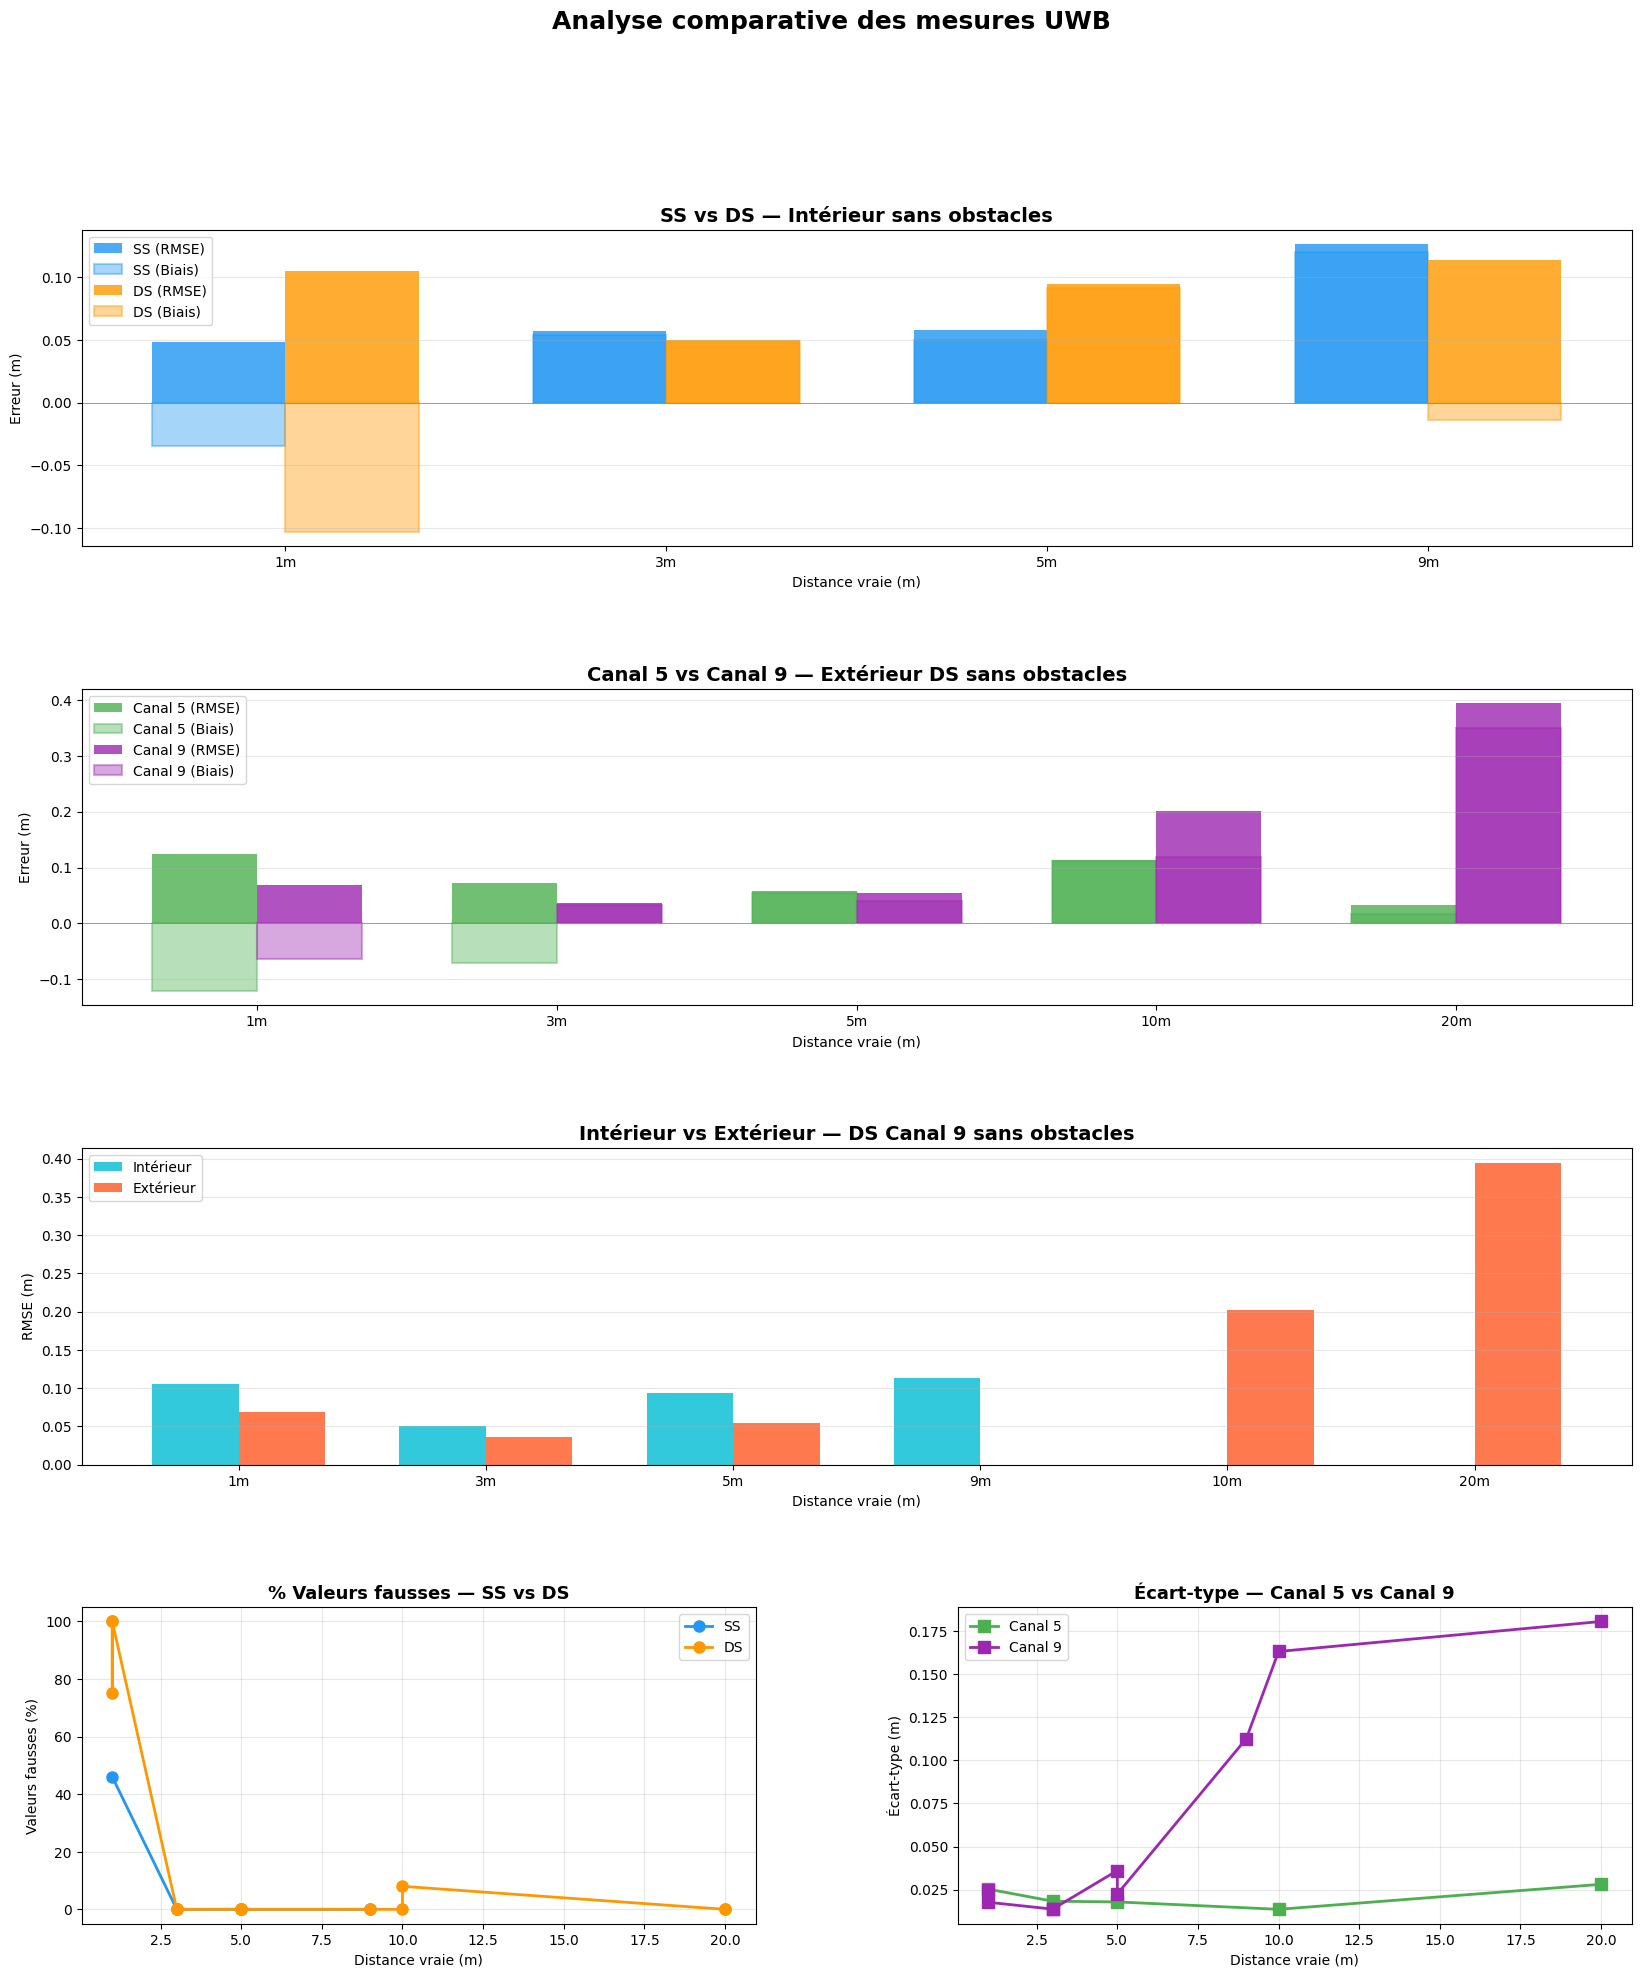


Figure sauvegardée : comparaison_uwb.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# === Classification automatique de chaque fichier ===
def classifier(chemin):
    chemin_lower = chemin.lower()
    
    # Environnement
    if "extérieur" in chemin_lower or "exterieur" in chemin_lower:
        env = "Extérieur"
    elif "intérieur" in chemin_lower or "interieur" in chemin_lower:
        env = "Intérieur"
    else:
        env = "Inconnu"
    
    # Ranging : SS ou DS
    if "single side" in chemin_lower or " ss " in chemin_lower or chemin_lower.startswith("ss "):
        ranging = "SS"
    elif "double side" in chemin_lower or " ds " in chemin_lower:
        ranging = "DS"
    else:
        ranging = "DS"  # par défaut (dossier double side)
    
    # Canal
    if "canal 5" in chemin_lower or "canal5" in chemin_lower:
        canal = "Canal 5"
    elif "canal 9" in chemin_lower or "canal9" in chemin_lower:
        canal = "Canal 9"
    else:
        canal = "Canal 9"  # par défaut pour intérieur
    
    # Obstacle
    if "sans obstacle" in chemin_lower or "sans obsctacle" in chemin_lower:
        obstacle = "Sans obstacle"
    elif "humain" in chemin_lower:
        obstacle = "Obstacle humain"
    elif "métal" in chemin_lower or "metal" in chemin_lower:
        obstacle = "Obstacle métal"
    elif "wifi" in chemin_lower:
        obstacle = "Perturbation WiFi"
    else:
        obstacle = "Autre"
    
    return env, ranging, canal, obstacle

# Enrichir df_stats avec les classifications
df_stats["Environnement"] = df_stats["Fichier"].apply(lambda f: classifier(f)[0])
df_stats["Ranging"] = df_stats["Fichier"].apply(lambda f: classifier(f)[1])
df_stats["Canal"] = df_stats["Fichier"].apply(lambda f: classifier(f)[2])
df_stats["Obstacle"] = df_stats["Fichier"].apply(lambda f: classifier(f)[3])

# Nom court pour les graphiques
def nom_court(fichier):
    parts = fichier.replace("\\", "/").split("/")
    return parts[-1].replace(".csv", "")

df_stats["Nom"] = df_stats["Fichier"].apply(nom_court)

print("Classification des fichiers :")
print(df_stats[["Nom", "Distance vraie (m)", "Environnement", "Ranging", "Canal", "Obstacle"]].to_string(index=False))

# === GRAPHIQUES COMPARATIFS ===
couleurs = {"SS": "#2196F3", "DS": "#FF9800"}
couleurs_canal = {"Canal 5": "#4CAF50", "Canal 9": "#9C27B0"}
couleurs_env = {"Intérieur": "#00BCD4", "Extérieur": "#FF5722"}

fig = plt.figure(figsize=(20, 22))
fig.suptitle("Analyse comparative des mesures UWB", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 2, hspace=0.45, wspace=0.3)

# --- 1. SS vs DS (intérieur, sans obstacles) ---
ax1 = fig.add_subplot(gs[0, :])
mask_ranging = (df_stats["Environnement"] == "Intérieur") & (df_stats["Obstacle"] == "Sans obstacle")
df_ranging = df_stats[mask_ranging].copy()

if not df_ranging.empty:
    distances = sorted(df_ranging["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    width = 0.35
    for i, ranging in enumerate(["SS", "DS"]):
        subset = df_ranging[df_ranging["Ranging"] == ranging]
        vals_rmse = []
        vals_biais = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals_rmse.append(s["RMSE (m)"].values[0] if len(s) > 0 else 0)
            vals_biais.append(s["Biais (m)"].values[0] if len(s) > 0 else 0)
        ax1.bar(x + i * width, vals_rmse, width, label=f"{ranging} (RMSE)", color=couleurs[ranging], alpha=0.8)
        ax1.bar(x + i * width, vals_biais, width, label=f"{ranging} (Biais)", color=couleurs[ranging], alpha=0.4, edgecolor=couleurs[ranging], linewidth=1.5)
    ax1.set_xlabel("Distance vraie (m)")
    ax1.set_ylabel("Erreur (m)")
    ax1.set_title("SS vs DS — Intérieur sans obstacles", fontsize=14, fontweight="bold")
    ax1.set_xticks(x + width / 2)
    ax1.set_xticklabels([f"{int(d)}m" for d in distances])
    ax1.legend()
    ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax1.grid(axis='y', alpha=0.3)

# --- 2. Canal 5 vs Canal 9 (extérieur, DS, sans obstacles) ---
ax2 = fig.add_subplot(gs[1, :])
mask_canal = (df_stats["Environnement"] == "Extérieur") & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS")
df_canal = df_stats[mask_canal].copy()

if not df_canal.empty:
    distances = sorted(df_canal["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    width = 0.35
    for i, canal in enumerate(["Canal 5", "Canal 9"]):
        subset = df_canal[df_canal["Canal"] == canal]
        vals_rmse = []
        vals_biais = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals_rmse.append(s["RMSE (m)"].values[0] if len(s) > 0 else 0)
            vals_biais.append(s["Biais (m)"].values[0] if len(s) > 0 else 0)
        ax2.bar(x + i * width, vals_rmse, width, label=f"{canal} (RMSE)", color=couleurs_canal[canal], alpha=0.8)
        ax2.bar(x + i * width, vals_biais, width, label=f"{canal} (Biais)", color=couleurs_canal[canal], alpha=0.4, edgecolor=couleurs_canal[canal], linewidth=1.5)
    ax2.set_xlabel("Distance vraie (m)")
    ax2.set_ylabel("Erreur (m)")
    ax2.set_title("Canal 5 vs Canal 9 — Extérieur DS sans obstacles", fontsize=14, fontweight="bold")
    ax2.set_xticks(x + width / 2)
    ax2.set_xticklabels([f"{int(d)}m" for d in distances])
    ax2.legend()
    ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax2.grid(axis='y', alpha=0.3)

# --- 3. Intérieur vs Extérieur (DS, canal 9, sans obstacles) ---
ax3 = fig.add_subplot(gs[2, :])
mask_env = (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS") & (df_stats["Canal"] == "Canal 9")
df_env = df_stats[mask_env].copy()

if not df_env.empty:
    distances = sorted(df_env["Distance vraie (m)"].unique())
    x = np.arange(len(distances))
    width = 0.35
    for i, env in enumerate(["Intérieur", "Extérieur"]):
        subset = df_env[df_env["Environnement"] == env]
        vals_rmse = []
        for d in distances:
            s = subset[subset["Distance vraie (m)"] == d]
            vals_rmse.append(s["RMSE (m)"].values[0] if len(s) > 0 else 0)
        ax3.bar(x + i * width, vals_rmse, width, label=f"{env}", color=couleurs_env[env], alpha=0.8)
    ax3.set_xlabel("Distance vraie (m)")
    ax3.set_ylabel("RMSE (m)")
    ax3.set_title("Intérieur vs Extérieur — DS Canal 9 sans obstacles", fontsize=14, fontweight="bold")
    ax3.set_xticks(x + width / 2)
    ax3.set_xticklabels([f"{int(d)}m" for d in distances])
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

# --- 4. % Valeurs fausses SS vs DS ---
ax4 = fig.add_subplot(gs[3, 0])
for ranging in ["SS", "DS"]:
    subset = df_stats[(df_stats["Ranging"] == ranging) & (df_stats["Obstacle"] == "Sans obstacle")]
    if not subset.empty:
        subset_sorted = subset.sort_values("Distance vraie (m)")
        ax4.plot(subset_sorted["Distance vraie (m)"], subset_sorted["Valeurs fausses (%)"],
                 'o-', label=ranging, color=couleurs[ranging], linewidth=2, markersize=8)
ax4.set_xlabel("Distance vraie (m)")
ax4.set_ylabel("Valeurs fausses (%)")
ax4.set_title("% Valeurs fausses — SS vs DS", fontsize=13, fontweight="bold")
ax4.legend()
ax4.grid(alpha=0.3)

# --- 5. Écart-type Canal 5 vs Canal 9 ---
ax5 = fig.add_subplot(gs[3, 1])
for canal in ["Canal 5", "Canal 9"]:
    subset = df_stats[(df_stats["Canal"] == canal) & (df_stats["Obstacle"] == "Sans obstacle") & (df_stats["Ranging"] == "DS")]
    if not subset.empty:
        subset_sorted = subset.sort_values("Distance vraie (m)")
        ax5.plot(subset_sorted["Distance vraie (m)"], subset_sorted["Écart-type (m)"],
                 's-', label=canal, color=couleurs_canal[canal], linewidth=2, markersize=8)
ax5.set_xlabel("Distance vraie (m)")
ax5.set_ylabel("Écart-type (m)")
ax5.set_title("Écart-type — Canal 5 vs Canal 9", fontsize=13, fontweight="bold")
ax5.legend()
ax5.grid(alpha=0.3)

plt.savefig(r"C:\Projet-IESE5-Localisation\comparaison_uwb.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure sauvegardée : comparaison_uwb.png")